In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import yaml
import os
from catboost import Pool
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from src.feature_generation.make_features import make_features_and_save

config_path = 'configs/features_config_30d.yaml'
with open(config_path, 'r') as config_file:
        config = yaml.safe_load(config_file)

In [6]:
countries_train = ["Dem_Rep_Korea",
                       "Russian_Federation",
                       "Finland",
                       "Norway",
                       "Sweden",
                       # "Denmark",
                       "Lithuania",
                       "Latvia",
                       "Estonia",
                       "Poland",
                       "Czech_Republic",
                       # "Germany",
                       "Hungary",
                       "Slovakia",
                       "Belarus",
                       "Ukraine",
                       "Moldova",
                       "Romania",
                       "Bulgaria",
                       "Albania",
                       "Montenegro",
                       "North_Macedonia",
                       "Kosovo",
                       "Serbia",
                       "Croatia",
                       "Bosnia_and_Herzegovina",
                       "Slovenia",
                       "Greece",
                       "Turkey",
                       "Georgia",
                       "Azerbaijan",
                        "Armenia",
                       "Kazakhstan",
                       "Kyrgyzstan",
                       "Tajikistan",
                       "Mongolia",
                       # "China",
                       # "Japan",
                       # "Republic_of_Korea"
                       ]

countries_df_list = []


full_data_path = 'data/saved_features_boost/train_test_features_30d_all_extended_north_14cb_new.parquet'
if not os.path.exists(full_data_path):
    for country in countries_train:
        df_country = pd.read_parquet(f'data/saved_features/train_test_features_30d_{country}.parquet')
        if country == "Ukraine":
            # Remove data after 2022-02-24 because of the war
            df_country = df_country[df_country['datetime'] < '2022-02-24']
        countries_df_list.append(df_country)

    df = pd.concat(countries_df_list)
    df = df.sort_values('datetime')
    #save final_df
    df.to_parquet(full_data_path)
else:
    df = pd.read_parquet(full_data_path)



with open(config['selected_feature_columns_path'], 'r') as f:
    selected_features = [line.strip() for line in f.readlines()]

#Check if all selected columns are in the dataframe
assert all(col in df.columns for col in selected_features)


In [7]:
target_col = 'count'
df['population'] = df['population'].fillna(0)
df['population'] = df['population'].astype(int)

cat_features = config['cat_features']
numerical_cat_features = config['numerical_cat_features']

for col in cat_features:
    if col in numerical_cat_features:
        df[col] = df[col].astype(int)
    else:
        df[col] = df[col].astype(str)

X = df.drop(columns=[target_col])
y = df[target_col]
#X  = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)

print(f"Train start year: {X_train['datetime'].min().year}")
print(f"Test start year: {X_test['datetime'].min().year}")
# Here Validation used as part of Train set, for prediction-ready model

Train start year: 2000
Test start year: 2021


In [17]:
y_train_binary = (y_train >0).astype(int)
y_test_binary = (y_test > 0).astype(int)

print(f"Train class balance: {y_train_binary.value_counts()}")
print(f"Test class balance: {y_test_binary.value_counts()}")


model_clf = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=0.35,
    bagging_temperature=0.96,
    min_data_in_leaf=80, 
    loss_function='Logloss',
    class_weights=[1,  1.5], 
    verbose=50, 
    ignored_features=["datetime", "day", "latitude", "longitude", "year"],
    cat_features=cat_features,
    feature_weights={'ecoregion_name':0.3,
                     "lat_rounded":0.3,
                     "lon_rounded":0.3,
                     },
    task_type='GPU',
)

model_clf.fit(X_train, y_train_binary)

Train class balance: count
0    1860659
1     312942
Name: count, dtype: int64
Test class balance: count
0    333163
1     50414
Name: count, dtype: int64
0:	learn: 0.6631195	total: 26.2ms	remaining: 26.2s
50:	learn: 0.3040442	total: 1.41s	remaining: 26.2s
100:	learn: 0.2729748	total: 2.8s	remaining: 24.9s
150:	learn: 0.2601981	total: 4.18s	remaining: 23.5s
200:	learn: 0.2516260	total: 5.57s	remaining: 22.1s
250:	learn: 0.2453697	total: 6.92s	remaining: 20.7s
300:	learn: 0.2400004	total: 8.28s	remaining: 19.2s
350:	learn: 0.2355623	total: 9.63s	remaining: 17.8s
400:	learn: 0.2319396	total: 11s	remaining: 16.4s
450:	learn: 0.2287850	total: 12.3s	remaining: 15s
500:	learn: 0.2256822	total: 13.7s	remaining: 13.6s
550:	learn: 0.2229289	total: 15s	remaining: 12.2s
600:	learn: 0.2203573	total: 16.3s	remaining: 10.9s
650:	learn: 0.2180274	total: 17.7s	remaining: 9.48s
700:	learn: 0.2155463	total: 19s	remaining: 8.12s
750:	learn: 0.2136030	total: 20.4s	remaining: 6.76s
800:	learn: 0.2116728	to

In [9]:
model_clf.save_model(config['model_path'])

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Train metrics
y_pred_binary = model_clf.predict(X_train)
accuracy = accuracy_score(y_train_binary, y_pred_binary)
precision = precision_score(y_train_binary, y_pred_binary)
recall = recall_score(y_train_binary, y_pred_binary)
f1 = f1_score(y_train_binary, y_pred_binary)  
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1: {f1}')


Accuracy: 0.927598027420856
Precision: 0.7580045441730102
Recall: 0.7302535294080054
F1: 0.7438703051786462


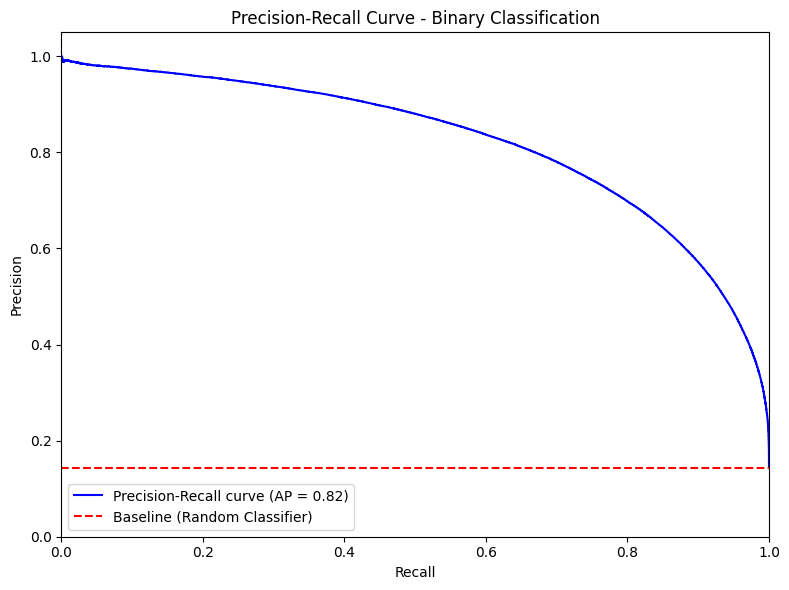

TRAIN PRECISION RECALL CURVE


In [19]:
from src.utils.plot_utils import plot_precision_recall_curve
y_pred_proba = model_clf.predict_proba(X_train)
plot_precision_recall_curve(y_train_binary, y_pred_proba)
print("TRAIN PRECISION RECALL CURVE")

In [20]:
y_pred_binary = model_clf.predict(X_test)

accuracy = accuracy_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)
recall = recall_score(y_test_binary, y_pred_binary)
f1 = f1_score(y_test_binary, y_pred_binary)  

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1: {f1}')

Accuracy: 0.929315365624112
Precision: 0.7266942968886814
Recall: 0.7408061252826595
F1: 0.7336823597591521


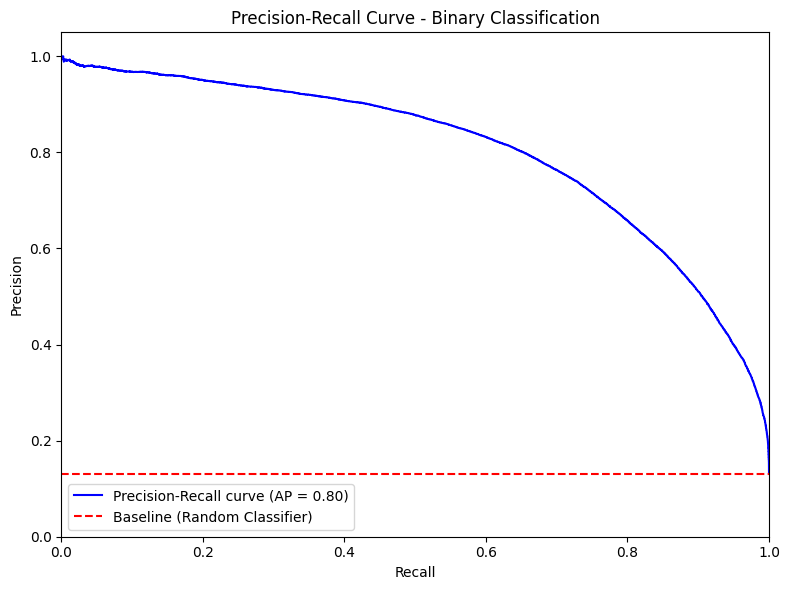

In [22]:
from src.utils.plot_utils import plot_precision_recall_curve
y_pred_proba = model_clf.predict_proba(X_test)
plot_precision_recall_curve(y_test_binary, y_pred_proba)

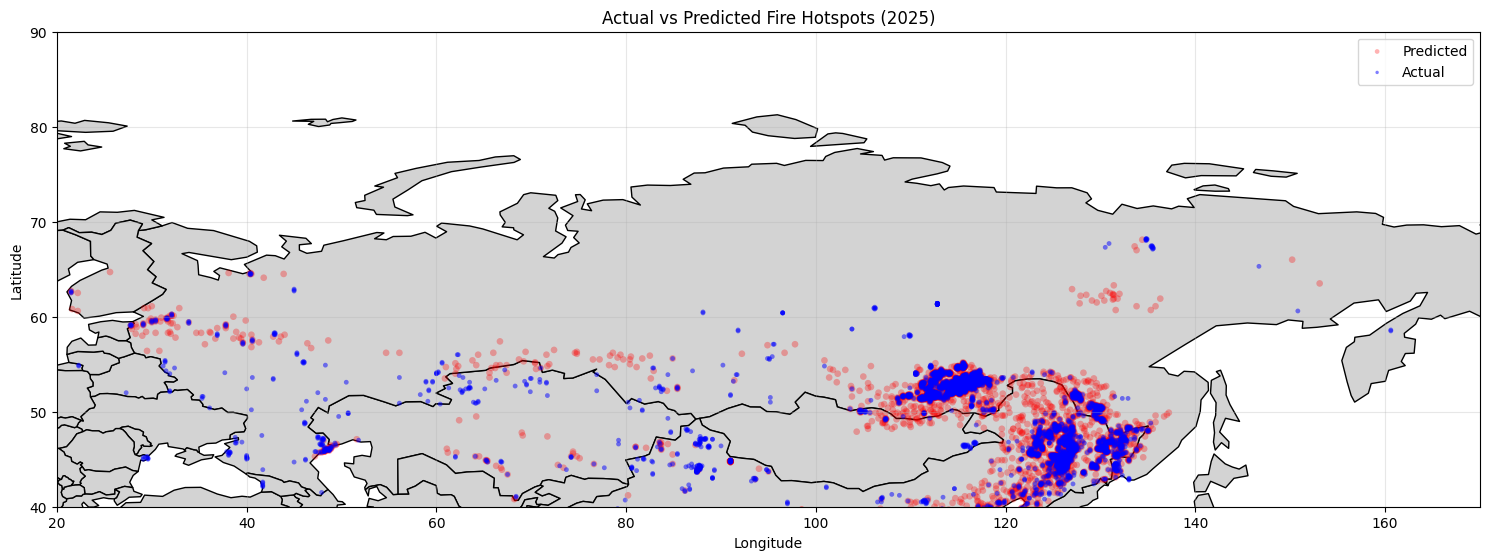

In [23]:
year = 2025
y_pred_binary = model_clf.predict(X_test)

assert len(X_test) == len(y_test_binary) == len(y_pred_binary)

year_mask = np.array(pd.to_datetime(X_test['datetime']).dt.year == year)
plt.style.use('seaborn-v0_8-bright')
fig, ax = plt.subplots(figsize=(15, 10))
world = gpd.read_file('data/countries')
world.plot(ax=ax, color='lightgrey', edgecolor='black')
lat = X_test['lat_rounded'][year_mask]
lon = X_test['lon_rounded'][year_mask]
pred_count = y_pred_binary[year_mask]
actual_count = y_test_binary[year_mask]

scatter_pred = plt.scatter(lon, 
                         lat,
                         c='red', s=pred_count * 23, 
                         alpha=0.3, label='Predicted', 
                         edgecolors='none')

scatter_actual = plt.scatter(lon, 
                             lat,
                           c='blue', s=actual_count * 12, 
                           alpha=0.5, label='Actual',
                           edgecolors='none')

ax.set_xlim(20, 170)
ax.set_ylim(40, 90)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Actual vs Predicted Fire Hotspots ({year})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

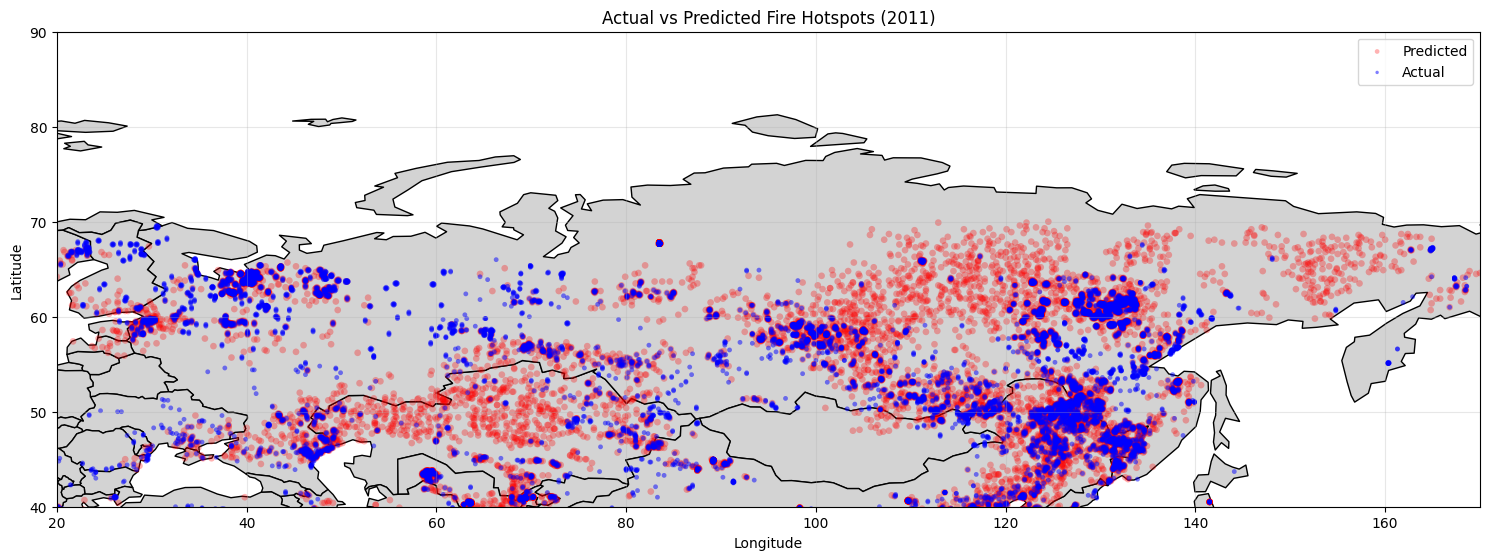

In [15]:
year = 2011

y_pred_binary = model_clf.predict(X_train)
assert len(X_train) == len(y_train_binary) == len(y_pred_binary)

year_mask = np.array(pd.to_datetime(X_train['datetime']).dt.year == year)
plt.style.use('seaborn-v0_8-bright')
fig, ax = plt.subplots(figsize=(15, 10))
world = gpd.read_file('data/countries')
world.plot(ax=ax, color='lightgrey', edgecolor='black')
lat = X_train['lat_rounded'][year_mask]
lon = X_train['lon_rounded'][year_mask]
pred_count = y_pred_binary[year_mask]
actual_count = y_train_binary[year_mask]

scatter_pred = plt.scatter(lon, 
                         lat,
                         c='red', s=pred_count * 23, 
                         alpha=0.3, label='Predicted', 
                         edgecolors='none')

scatter_actual = plt.scatter(lon, 
                             lat,
                           c='blue', s=actual_count * 12, 
                           alpha=0.5, label='Actual',
                           edgecolors='none')

ax.set_xlim(20, 170)
ax.set_ylim(40, 90)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Actual vs Predicted Fire Hotspots ({year})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [24]:
# Feature importance
feature_importance = model_clf.get_feature_importance()
feature_names = model_clf.feature_names_
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
feature_importance_df.head(50)

,feature,importance
244,ecoregion_name,8.375528
232,population,5.089371
223,fire_index_fwinx_mean,4.733424
166,stl1_trend_slope_90,4.709794
81,d2m_std_120,3.102931
36,t2m_ewm_7,2.519649
11,t2m_mean_7,2.432431
13,t2m_min_7,2.416827
229,lai_hv,2.352527
241,tvh,2.053852


In [13]:
for col in feature_importance_df['feature']:
    print(col)

ecoregion_name
stl1_trend_slope_90
population
t2m_ewm_7
fire_index_fwinx_median
tvh
fire_index_fwinx_mean
fire_index_fdsrte_median
fire_index_fdsrte_mean
stl1_std_120
lai_hv
tvl
t2m_max_90
d2m_std_120
t2m_diff_90
stl1_median_14
tp_min_30
month
stl1_min_7
d2m_max_120
t2m_max_30
t2m_lag_120
stl1_mean_120
distance_to_coast_dilated_km
d2m_trend_slope_90
t2m_std_90
fire_index_drtcode_max
sdfor
lai_lv
t2m_median_30
t2m_trend_slope_90
stl1_trend_slope_21
z
t2m_median_90
fire_index_drtcode_min
fire_index_ffmcode_median
elevation_max_0.2deg
fire_index_ffmcode_max
t2m_mean_7
d2m_ewm_120
t2m_pct_change_90
d2m_min_120
tp_ewm_7
t2m_min_14
t2m_mean_30
d2m_max_30
stl1_median_90
stl1_median_7
t2m_std_120
t2m_ewm_14
stl1_max_7
tp_max_30
tp_ewm_30
fire_index_drtcode_std
stl1_trend_intercept_90
landseamask
d2m_median_7
fire_index_drtcode_mean
fire_index_fdsrte_std
d2m_std_30
fire_index_drtcode_median
elevation_min_0.2deg
d2m_median_120
fire_index_ffmcode_mean
t2m_diff_7
stl1_std_90
d2m_std_90
stl1_max_90